✅ Libraries imported!
Using: cuda
GPU: Tesla T4
✅ Labeled Flooded     : 51 files
✅ Labeled NonFlooded  : 347 files
✅ Unlabeled           : 1047 files
✅ Validation          : 450 files
✅ Test                : 448 files

=== Dataset Summary ===
Train labeled   :   398  (paper: 398)
  Flooded       :    51  (paper:  51)
  Non-Flooded   :   347  (paper: 347)
Train unlabeled :  1047  (paper: 1047)
Validation      :   450  (paper: 450)
Test            :   448  (paper: 448)

✅ DataLoaders ready!
  Labeled batches   : 25
  Unlabeled batches : 66
  Val batches       : 29
  Test batches      : 28
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 230MB/s] 



✅ VGG-16 loaded on cuda
Total params     : 134,264,641
Trainable params : 134,264,641

✅ Hyperparameters set — exact from paper!
  LR=0.0001 | Epochs=50 | Batch=16 | Lambda=0.2
  Phase 1 (supervised only) : epochs  0 - 19
  Phase 2 (alpha ramps 0→1) : epochs 20 - 39
  Phase 3 (full semi-sup)   : epochs 40 - 49

🚀 Starting VGG-16 Training on cuda
Saving best model to: /kaggle/working/best_vgg16_floodnet.pth
  ✅ Best model saved! F1=28.57%
Ep[01/50] α=0.00 | TrLoss=0.3316 | ValLoss=4.441 | Acc=16.67% | F1=28.57% | Pseudo=0 | 110.9s
  ✅ Best model saved! F1=42.38%
Ep[02/50] α=0.00 | TrLoss=0.1532 | ValLoss=2.157 | Acc=26.89% | F1=42.38% | Pseudo=0 | 104.0s
Ep[03/50] α=0.00 | TrLoss=0.1305 | ValLoss=6.835 | Acc=8.89% | F1=16.33% | Pseudo=0 | 103.0s
Ep[04/50] α=0.00 | TrLoss=0.0186 | ValLoss=9.254 | Acc=15.11% | F1=26.25% | Pseudo=0 | 100.9s
Ep[05/50] α=0.00 | TrLoss=0.0621 | ValLoss=7.684 | Acc=8.00% | F1=14.81% | Pseudo=0 | 102.6s
Ep[06/50] α=0.00 | TrLoss=0.0355 | ValLoss=10.111 | Acc=1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1179: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


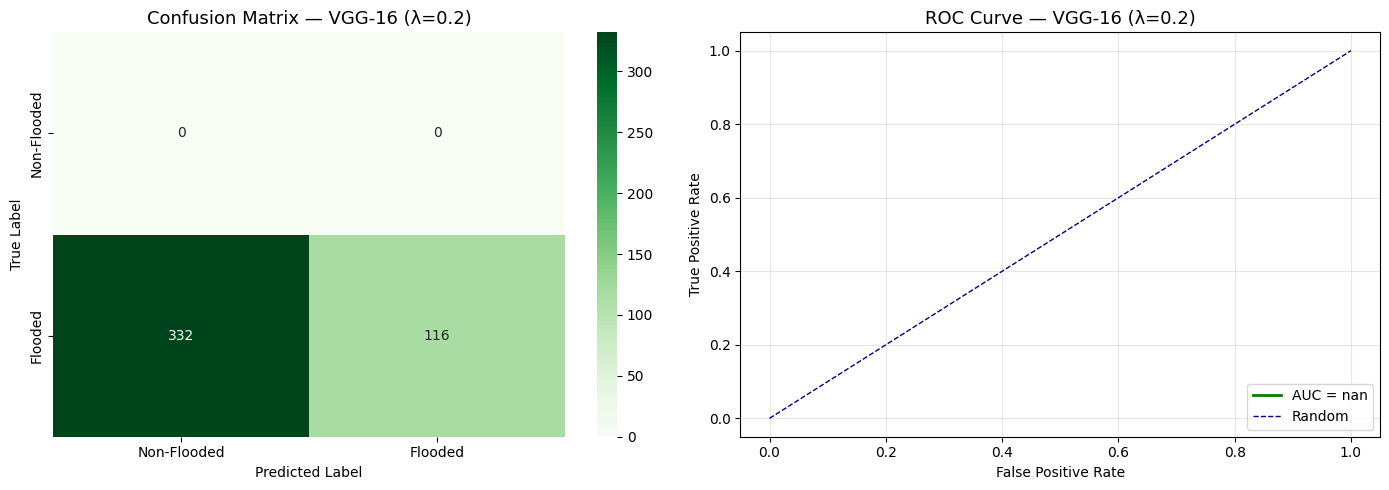

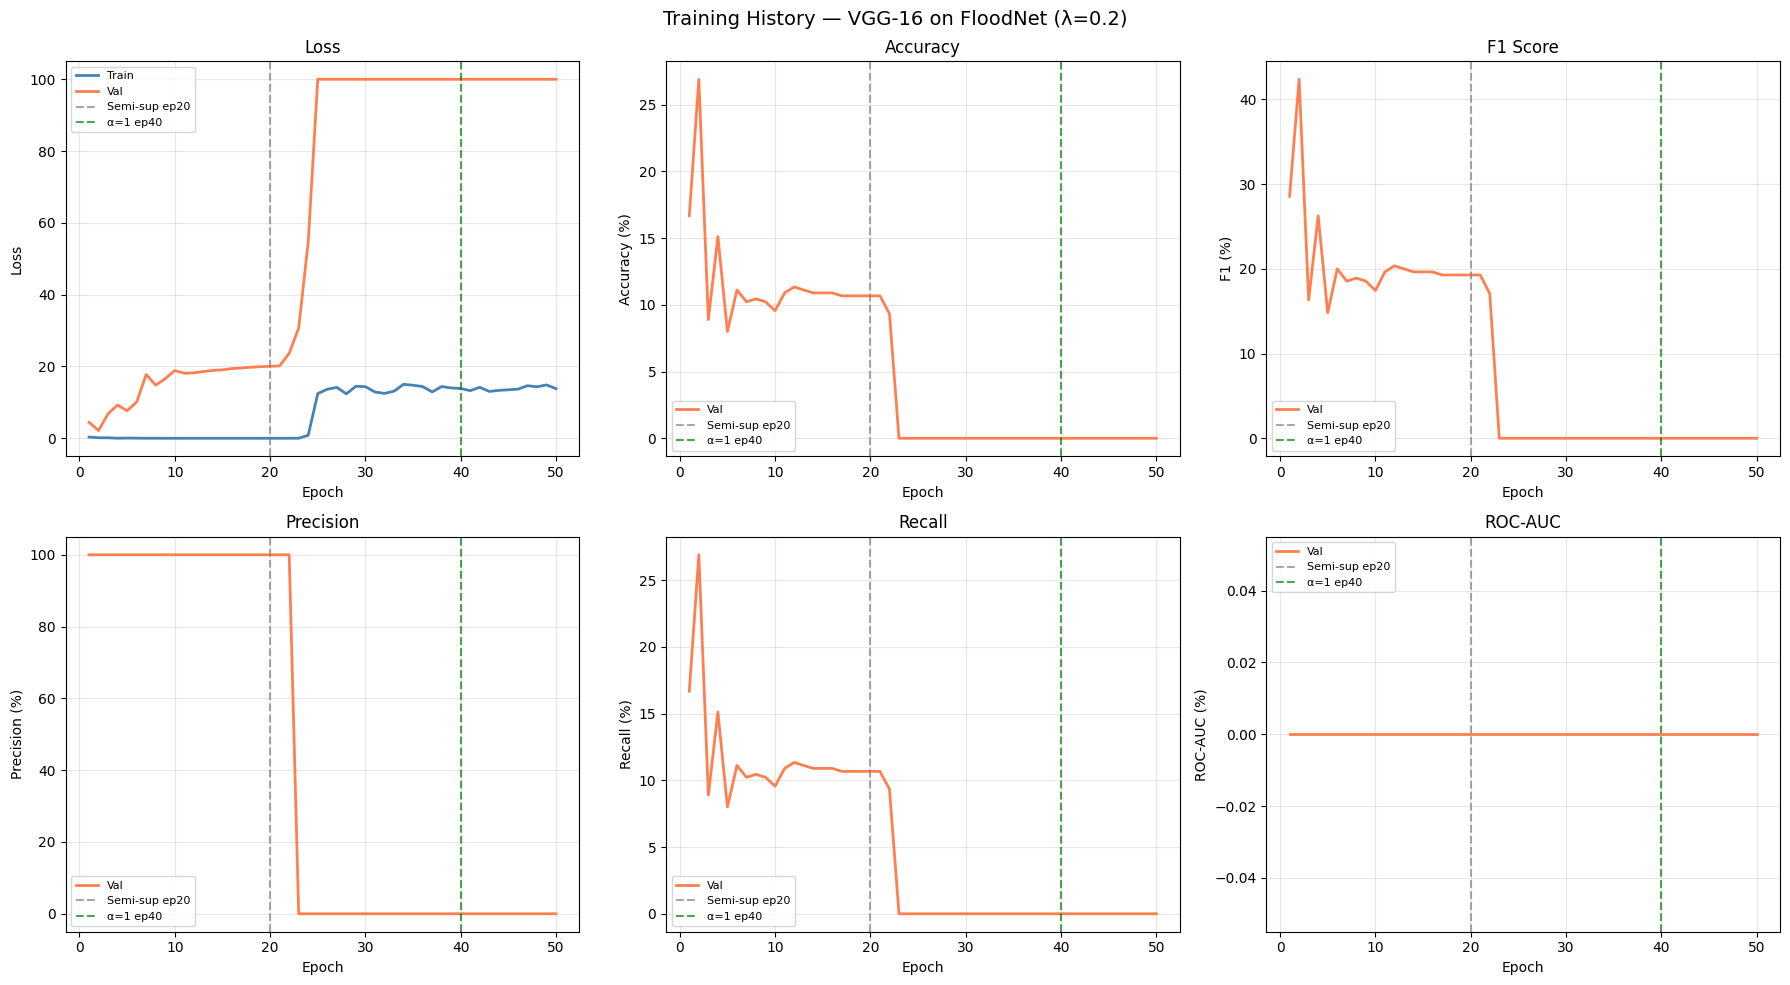


✅ VGG-16 DONE!
Files saved to /kaggle/working/:
  → best_vgg16_floodnet.pth
  → vgg16_confusion_roc.png
  → vgg16_training_history.png


In [1]:
# ============================================================
# VGG-16 FLOODNET — KAGGLE VERSION (ONE CELL)
# Paper: Table 2 — VGG-16 results:
# Loss=0.096, Acc=97.368, F1=90.214, Prec=100, Recall=100, ROC-AUC=98.251
# ============================================================

# ── 1. Imports ──
import os, time, glob, torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score,
                             confusion_matrix, roc_curve, auc)

print('✅ Libraries imported!')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ── 2. Dataset Paths ──
BASE = '/kaggle/input/datasets/aletbm/aerial-imagery-dataset-floodnet-challenge/FloodNet Challenge - Track 1'

LABELED_FLOODED    = os.path.join(BASE, 'Train', 'Labeled', 'Flooded',     'image')
LABELED_NONFLOODED = os.path.join(BASE, 'Train', 'Labeled', 'Non-Flooded', 'image')
UNLABELED          = os.path.join(BASE, 'Train', 'Unlabeled', 'image')
VAL_BASE           = os.path.join(BASE, 'Validation')
TEST_BASE          = os.path.join(BASE, 'Test')

# Verify paths
for name, path in [('Labeled Flooded',    LABELED_FLOODED),
                   ('Labeled NonFlooded', LABELED_NONFLOODED),
                   ('Unlabeled',          UNLABELED),
                   ('Validation',         VAL_BASE),
                   ('Test',               TEST_BASE)]:
    exists = '✅' if os.path.exists(path) else '❌'
    count  = sum(len(f) for _, _, f in os.walk(path)) if os.path.exists(path) else 0
    print(f'{exists} {name:<20}: {count} files')

# ── 3. Build Image & Label Lists ──
def get_images(folder):
    return sorted(
        glob.glob(os.path.join(folder, '*.jpg'))  +
        glob.glob(os.path.join(folder, '*.png'))  +
        glob.glob(os.path.join(folder, '*.jpeg'))
    )

def get_labeled_split(split_base):
    labeled = []
    flooded_dir    = os.path.join(split_base, 'Flooded',     'image')
    nonflooded_dir = os.path.join(split_base, 'Non-Flooded', 'image')
    if os.path.exists(flooded_dir):
        labeled += [(p, 1) for p in get_images(flooded_dir)]
    if os.path.exists(nonflooded_dir):
        labeled += [(p, 0) for p in get_images(nonflooded_dir)]
    if not labeled:
        img_dir = os.path.join(split_base, 'image')
        for p in get_images(img_dir):
            labeled.append((p, 1))
    return labeled

flooded_imgs    = [(p, 1) for p in get_images(LABELED_FLOODED)]
nonflooded_imgs = [(p, 0) for p in get_images(LABELED_NONFLOODED)]
train_labeled   = flooded_imgs + nonflooded_imgs
train_unlabeled = get_images(UNLABELED)
val_data        = get_labeled_split(VAL_BASE)
test_data       = get_labeled_split(TEST_BASE)

if len(val_data)  == 0: val_data  = [(p, 1) for p in get_images(os.path.join(VAL_BASE,  'image'))]
if len(test_data) == 0: test_data = [(p, 1) for p in get_images(os.path.join(TEST_BASE, 'image'))]

print('\n=== Dataset Summary ===')
print(f'Train labeled   : {len(train_labeled):>5}  (paper: 398)')
print(f'  Flooded       : {len(flooded_imgs):>5}  (paper:  51)')
print(f'  Non-Flooded   : {len(nonflooded_imgs):>5}  (paper: 347)')
print(f'Train unlabeled : {len(train_unlabeled):>5}  (paper: 1047)')
print(f'Validation      : {len(val_data):>5}  (paper: 450)')
print(f'Test            : {len(test_data):>5}  (paper: 448)')

# ── 4. Dataset Classes ──
# Paper: 224x224 input, NO augmentation, ImageNet normalization
# VGG-16 paper: accepts 224x224 with 3 RGB channels
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

class LabeledDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.float32)

class UnlabeledDataset(Dataset):
    def __init__(self, paths, transform=None):
        self.paths     = paths
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.paths[idx]

def make_weighted_sampler(samples):
    labels         = [l for _, l in samples]
    class_counts   = np.bincount(labels)
    class_weights  = 1.0 / class_counts
    sample_weights = [class_weights[l] for l in labels]
    return WeightedRandomSampler(
        weights    =sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

BATCH_SIZE = 16   # exact from paper

labeled_ds   = LabeledDataset(train_labeled,    transform)
unlabeled_ds = UnlabeledDataset(train_unlabeled, transform)
val_ds       = LabeledDataset(val_data,          transform)
test_ds      = LabeledDataset(test_data,         transform)

sampler = make_weighted_sampler(train_labeled)

labeled_loader   = DataLoader(labeled_ds,   batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
unlabeled_loader = DataLoader(unlabeled_ds, batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)
val_loader       = DataLoader(val_ds,       batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)
test_loader      = DataLoader(test_ds,      batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)

print('\n✅ DataLoaders ready!')
print(f'  Labeled batches   : {len(labeled_loader)}')
print(f'  Unlabeled batches : {len(unlabeled_loader)}')
print(f'  Val batches       : {len(val_loader)}')
print(f'  Test batches      : {len(test_loader)}')

# ── 5. VGG-16 Model ──
# Paper Section 3.3:
# - 16 layers (13 conv + 3 dense)
# - 138 trainable parameters
# - Input: 224x224x3
# - 3x3 kernel, stride 1
# - 2x2 max pooling
# - Conv1=64, Conv2=128, Conv3=256, Conv4&5=512 filters
def build_vgg16():
    # Pretrained ImageNet weights (same as ResNet-18 setup)
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

    # Replace final classifier layer for binary classification
    # VGG-16 classifier: [fc1(4096), fc2(4096), fc3(1000)]
    # We replace fc3 with fc3(1) + Sigmoid
    in_features = model.classifier[6].in_features  # 4096
    model.classifier[6] = nn.Sequential(
        nn.Linear(in_features, 1),
        nn.Sigmoid()
    )
    return model

model = build_vgg16().to(DEVICE)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n✅ VGG-16 loaded on {DEVICE}')
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {trainable_params:,}')

# ── 6. Hyperparameters — ALL exact from paper ──
# Same hyperparameters for ALL models in the paper
LR     = 0.0001   # Adam lr
EPOCHS = 50       # total epochs
E_ai   = 20       # supervised-only phase ends
E_af   = 40       # alpha ramp ends
a_i    = 0.0      # starting alpha
a_f    = 1.0      # final alpha
LAMBDA = 0.2      # best uncertainty offset (Table 1)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.BCELoss()

def compute_alpha(epoch):
    # Algorithm 1 from paper
    if epoch < E_ai:
        return 0.0
    elif epoch < E_af:
        return (a_f - a_i) / (E_af - E_ai) * (epoch - E_ai) + a_i
    else:
        return 1.0

def assign_pseudo_labels(model, loader, lam, device):
    # Algorithm 1 uncertainty offset rule
    model.eval()
    pseudo = []
    with torch.no_grad():
        for imgs, _ in loader:
            imgs  = imgs.to(device)
            probs = model(imgs).squeeze(1)
            for i, p in enumerate(probs):
                pv = p.item()
                if pv <= (0.5 - lam):
                    pseudo.append((imgs[i].cpu(), 0))
                elif pv > (0.5 + lam):
                    pseudo.append((imgs[i].cpu(), 1))
    return pseudo

print('\n✅ Hyperparameters set — exact from paper!')
print(f'  LR={LR} | Epochs={EPOCHS} | Batch={BATCH_SIZE} | Lambda={LAMBDA}')
print(f'  Phase 1 (supervised only) : epochs  0 - {E_ai-1}')
print(f'  Phase 2 (alpha ramps 0→1) : epochs {E_ai} - {E_af-1}')
print(f'  Phase 3 (full semi-sup)   : epochs {E_af} - {EPOCHS-1}')

# ── 7. Evaluation Function (all 6 paper metrics) ──
def evaluate(model, loader, criterion, device):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    total_loss = 0.0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            probs        = model(imgs).squeeze(1)
            total_loss  += criterion(probs, labels).item() * imgs.size(0)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend((probs >= 0.5).long().cpu().numpy())
            all_labels.extend(labels.cpu().long().numpy())
    has_both = len(set(all_labels)) > 1
    return {
        'loss'     : round(total_loss / len(loader.dataset), 3),
        'accuracy' : round(accuracy_score(all_labels, all_preds) * 100, 3),
        'f1'       : round(f1_score(all_labels, all_preds, zero_division=0) * 100, 3),
        'precision': round(precision_score(all_labels, all_preds, zero_division=0) * 100, 3),
        'recall'   : round(recall_score(all_labels, all_preds, zero_division=0) * 100, 3),
        'roc_auc'  : round(roc_auc_score(all_labels, all_probs) * 100 if has_both else 0.0, 3)
    }

# ── 8. Training Loop ──
SAVE_PATH = '/kaggle/working/best_vgg16_floodnet.pth'

history = {k: [] for k in [
    'train_loss', 'val_loss', 'val_accuracy',
    'val_f1', 'val_precision', 'val_recall', 'val_roc_auc', 'alpha'
]}
best_val_f1, best_epoch, best_metrics = 0.0, 0, {}

print(f'\n🚀 Starting VGG-16 Training on {DEVICE}')
print(f'Saving best model to: {SAVE_PATH}')
print('='*80)

for epoch in range(EPOCHS):
    t0    = time.time()
    alpha = compute_alpha(epoch)
    history['alpha'].append(alpha)
    model.train()
    epoch_loss, n_batches = 0.0, 0

    # ── Labeled data (every epoch) ──
    for imgs, labels in labeled_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs).squeeze(1), labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        n_batches  += 1

    # ── Pseudo-labeled data (when alpha > 0) ──
    pseudo_count = 0
    if alpha > 0 and len(train_unlabeled) > 0:
        pseudo = assign_pseudo_labels(model, unlabeled_loader, LAMBDA, DEVICE)
        pseudo_count = len(pseudo)
        if pseudo_count > 0:
            model.train()
            p_imgs   = torch.stack([s[0] for s in pseudo]).to(DEVICE)
            p_labels = torch.tensor([s[1] for s in pseudo],
                                     dtype=torch.float32).to(DEVICE)
            for i in range(0, len(p_imgs), BATCH_SIZE):
                optimizer.zero_grad()
                loss = alpha * criterion(
                    model(p_imgs[i:i+BATCH_SIZE]).squeeze(1),
                    p_labels[i:i+BATCH_SIZE]
                )
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
                n_batches  += 1

    # ── Validate ──
    val_m    = evaluate(model, val_loader, criterion, DEVICE)
    avg_loss = epoch_loss / n_batches

    # ── Log ──
    history['train_loss'].append(avg_loss)
    history['val_loss'].append(val_m['loss'])
    history['val_accuracy'].append(val_m['accuracy'])
    history['val_f1'].append(val_m['f1'])
    history['val_precision'].append(val_m['precision'])
    history['val_recall'].append(val_m['recall'])
    history['val_roc_auc'].append(val_m['roc_auc'])

    # ── Save best ──
    if val_m['f1'] > best_val_f1:
        best_val_f1  = val_m['f1']
        best_epoch   = epoch
        best_metrics = val_m.copy()
        torch.save(model.state_dict(), SAVE_PATH)
        print(f'  ✅ Best model saved! F1={best_val_f1:.2f}%')

    print(f"Ep[{epoch+1:02d}/{EPOCHS}] "
          f"α={alpha:.2f} | "
          f"TrLoss={avg_loss:.4f} | "
          f"ValLoss={val_m['loss']:.3f} | "
          f"Acc={val_m['accuracy']:.2f}% | "
          f"F1={val_m['f1']:.2f}% | "
          f"Pseudo={pseudo_count} | "
          f"{time.time()-t0:.1f}s")

print('='*80)
print(f'\n🏆 Best VGG-16 model at Epoch {best_epoch+1}:')
for k, v in best_metrics.items():
    print(f'  {k:<12}: {v}')

# ── 9. Test Results vs Paper Table 2 ──
model.load_state_dict(torch.load(SAVE_PATH))
test_m = evaluate(model, test_loader, criterion, DEVICE)

# Paper Table 2 exact values for VGG-16
paper = {
    'loss'     : 0.096,
    'accuracy' : 97.368,
    'f1'       : 90.214,
    'precision': 100.0,
    'recall'   : 100.0,
    'roc_auc'  : 98.251
}

print('\n' + '='*55)
print('  TEST RESULTS — VGG-16 (λ=0.2)')
print('='*55)
print(f"  {'Metric':<12} {'Paper':>10} {'Ours':>10} {'Diff':>8}")
print('  ' + '-'*42)
for k in paper:
    diff = test_m[k] - paper[k]
    sign = '+' if diff >= 0 else ''
    print(f"  {k:<12} {paper[k]:>10.3f} {test_m[k]:>10.3f} {sign}{diff:>7.3f}")
print('='*55)

# ── 10. Confusion Matrix + ROC Curve ──
model.eval()
all_probs, all_preds, all_labels = [], [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        probs = model(imgs.to(DEVICE)).squeeze(1)
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend((probs >= 0.5).long().cpu().numpy())
        all_labels.extend(labels.long().numpy())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Non-Flooded', 'Flooded'],
            yticklabels=['Non-Flooded', 'Flooded'])
axes[0].set_title('Confusion Matrix — VGG-16 (λ=0.2)', fontsize=13)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_val = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='green', lw=2, label=f'AUC = {roc_val:.4f}')
axes[1].plot([0,1],[0,1], 'navy', lw=1, linestyle='--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — VGG-16 (λ=0.2)', fontsize=13)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/vgg16_confusion_roc.png', dpi=150)
plt.show()

# ── 11. Training History Plots ──
epochs_range = range(1, EPOCHS + 1)
fig, axes    = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training History — VGG-16 on FloodNet (λ=0.2)', fontsize=14)

plots = [
    ('Loss',      'train_loss', 'val_loss',      'Loss'),
    ('Accuracy',   None,        'val_accuracy',  'Accuracy (%)'),
    ('F1 Score',   None,        'val_f1',        'F1 (%)'),
    ('Precision',  None,        'val_precision', 'Precision (%)'),
    ('Recall',     None,        'val_recall',    'Recall (%)'),
    ('ROC-AUC',    None,        'val_roc_auc',   'ROC-AUC (%)'),
]

for ax, (title, tk, vk, ylabel) in zip(axes.flat, plots):
    if tk:
        ax.plot(epochs_range, history[tk], label='Train', color='steelblue', lw=2)
    ax.plot(epochs_range, history[vk], label='Val', color='coral', lw=2)
    ax.axvline(x=E_ai, color='gray',  linestyle='--', alpha=0.7, label=f'Semi-sup ep{E_ai}')
    ax.axvline(x=E_af, color='green', linestyle='--', alpha=0.7, label=f'α=1 ep{E_af}')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/vgg16_training_history.png', dpi=150)
plt.show()

print('\n✅ VGG-16 DONE!')
print('Files saved to /kaggle/working/:')
print('  → best_vgg16_floodnet.pth')
print('  → vgg16_confusion_roc.png')
print('  → vgg16_training_history.png')